# 02 — Exploratory Data Analysis & Performance Across Promotions

**Goal:** Understand grade distributions, promo-level differences, semester
progression, subject-level performance, and demographic breakdowns.
All using `panel.csv` from notebook 01.



## 1. Imports



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats

CLEAN = Path("../data/clean")
FIG   = Path("../figures/eda")
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="Set2")
PROMO_COLORS = {
    1: "#4C72B0",
    2: "#55A868",
    3: "#C44E52"
}

pd.set_option("display.float_format", "{:.2f}".format)

panel    = pd.read_csv(CLEAN / "panel.csv")
notes    = pd.read_csv(CLEAN / "notes_clean.csv")
matieres = pd.read_csv(CLEAN / "matieres_clean.csv")

print(f"Panel loaded: {panel.shape}")
print(panel.dtypes)

# ── Detect available grade / demographic columns ──────────────────────────────
grade_cols = [c for c in panel.columns
              if c not in ["id", "promo", "moy_s1", "moy_s2", "moy_ann",
                            "rang", "passage", "passage_bin", "rang_norm",
                            "delta_s2_s1", "top_quartile", "bottom_quartile",
                            "is_outlier", "genre", "origine", "bac",
                            "licence", "promotion"]
              and not c.startswith("mod_")]
mod_cols   = [c for c in panel.columns if c.startswith("mod_")]
demo_cols  = [c for c in ["genre", "origine", "bac", "licence"] if c in panel.columns]

print(f"\nGrade cols  : {grade_cols}")
print(f"Module cols : {mod_cols}")
print(f"Demo cols   : {demo_cols}")


Panel loaded: (100, 52)
id                                    str
promo                               int64
moy_s1                            float64
moy_s2                            float64
moy_ann                           float64
rang                                int64
passage                               str
promotion                           int64
genre                                 str
origine                               str
licence                               str
bac                                   str
Devp mob                          float64
TOEIC3                            float64
TOEIC4                            float64
agile                             float64
algo num2                         float64
algo.num1                         float64
appr auto                         float64
ches de mkv-fil d'at              float64
cloud comp                        float64
devops1                           float64
dt des entpses                    float64
ent de don

## 2. Promotion Summary Statistics



In [2]:
summary = (panel.groupby("promo")
           [["moy_s1", "moy_s2", "moy_ann", "delta_s2_s1"]]
           .agg(["mean", "std", "min", "max", "median"])
           .round(2))
print(summary)

# Passage rate per promo
passage = (panel.groupby(["promo", "passage"])
           .size().unstack(fill_value=0))
passage["total"] = passage.sum(axis=1)
for c in [col for col in passage.columns if col != "total"]:
    passage[f"{c}_%"] = (passage[c] / passage["total"] * 100).round(1)
print("\nPassage rates:")
print(passage)


      moy_s1                         moy_s2                         moy_ann  \
        mean  std   min   max median   mean  std   min   max median    mean   
promo                                                                         
1      12.38 1.58  7.71 15.70  12.61  12.17 2.16  4.09 16.16  12.76   12.27   
2      12.49 1.51  9.74 15.77  12.61  12.63 1.68  8.77 15.84  12.60   12.56   
3      12.70 1.27 10.04 15.48  12.59  13.12 1.45 10.72 16.29  12.96   12.91   

                              delta_s2_s1                         
       std   min   max median        mean  std   min  max median  
promo                                                             
1     1.82  5.90 15.93  12.65       -0.21 1.06 -3.62 1.25   0.01  
2     1.54  9.34 15.62  12.64        0.13 0.83 -1.67 1.61   0.19  
3     1.31 10.62 15.89  12.66        0.42 0.73 -1.12 1.53   0.47  

Passage rates:
passage  Admis  Rattrapage  total  Admis_%  Rattrapage_%
promo                                             

## 3. Distribution of Annual Averages by Promo



In [3]:
print(panel["promo"].unique())
print(type(panel["promo"].iloc[0]))
print(PROMO_COLORS.keys())


[2 3 1]
<class 'numpy.int64'>
dict_keys([1, 2, 3])


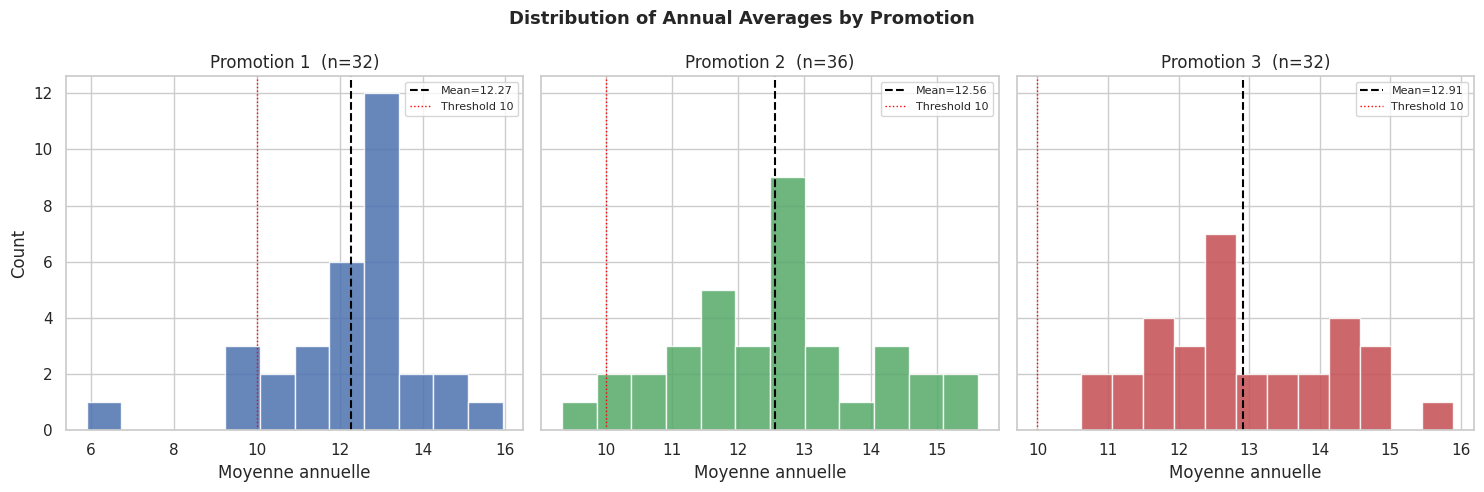

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, promo in zip(axes, [1, 2, 3]):
    data = panel[panel["promo"] == promo]["moy_ann"]
    ax.hist(data, bins=12, color=PROMO_COLORS[promo], edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(), color="black", lw=1.5, linestyle="--",
               label=f"Mean={data.mean():.2f}")
    ax.axvline(10, color="red", lw=1, linestyle=":", label="Threshold 10")
    ax.set_title(f"Promotion {promo}  (n={len(data)})")
    ax.set_xlabel("Moyenne annuelle")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Count")
fig.suptitle("Distribution of Annual Averages by Promotion", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "dist_moy_ann_by_promo.png", dpi=150)
plt.show()


## 4. Violin Plot — Promo Comparison



In [5]:
panel["promo_str"] = (
    panel["promo"]
    .astype(str)
    .str.extract(r"(\d)")   # keep only 1,2,3
)

/tmp/ipykernel_124855/2512459402.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_124855/2512459402.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_124855/2512459402.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


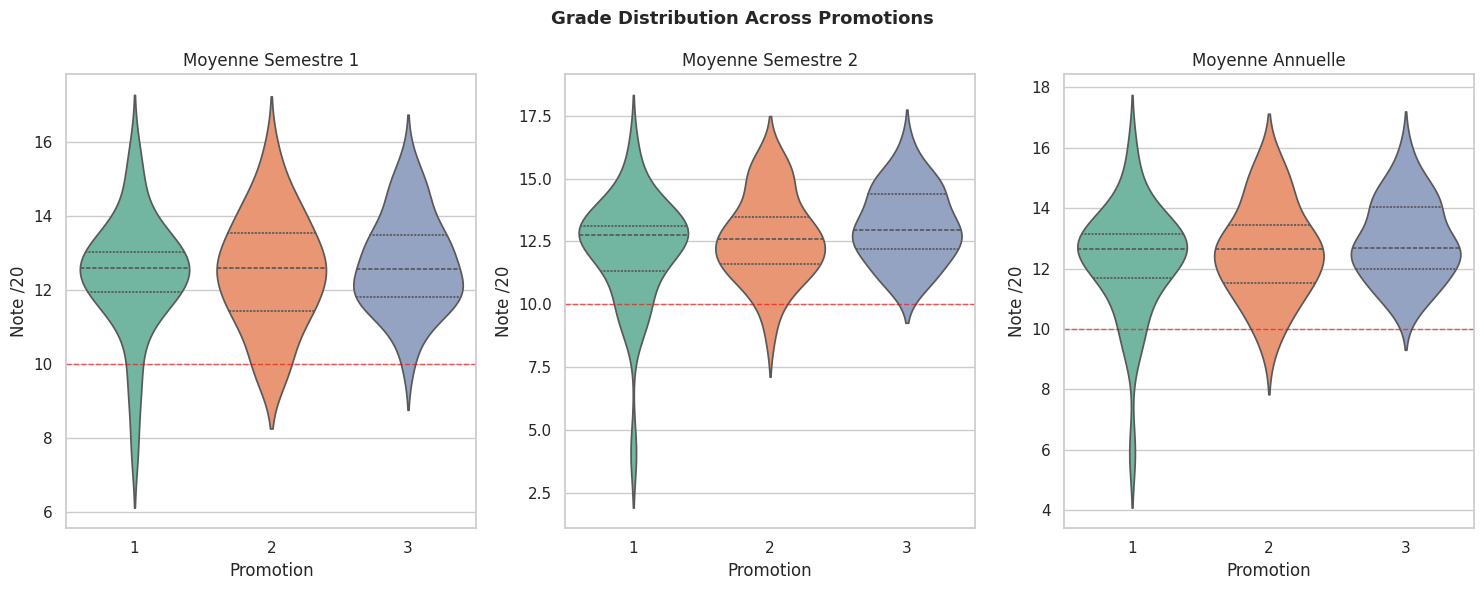

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
metrics = [("moy_s1", "Semestre 1"), ("moy_s2", "Semestre 2"), ("moy_ann", "Annuelle")]


for ax, (col, label) in zip(axes, metrics):
    sns.violinplot(
        data=panel,
        x="promo_str",
        y=col,
        palette="Set2",  
        order=["1", "2", "3"],
        inner="quartile",
        ax=ax
    )
    ax.axhline(10, color="red", lw=1, linestyle="--", alpha=0.6)
    ax.set_title(f"Moyenne {label}")
    ax.set_xlabel("Promotion")
    ax.set_ylabel("Note /20")

fig.suptitle("Grade Distribution Across Promotions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "violin_promos.png", dpi=150)
plt.show()


## 5. Statistical Tests — Are Promos Significantly Different?

Kruskal-Wallis test (non-parametric ANOVA) — does not assume normality.



In [7]:
for metric in ["moy_s1", "moy_s2", "moy_ann"]:
    groups = [panel[panel["promo"] == p][metric].dropna() for p in [1, 2, 3]]
    stat, pval = stats.kruskal(*groups)
    print(f"{metric:12s}: H={stat:.3f}, p={pval:.4f}  "
          f"{'*** SIGNIFICANT' if pval < 0.05 else '(not significant)'}")

# Post-hoc: Mann-Whitney pairwise with Bonferroni correction
print("\nPairwise Mann-Whitney (Bonferroni-corrected, alpha=0.05/3=0.0167):")
pairs = [(1,2), (1,3), (2,3)]
for (p1, p2) in pairs:
    g1 = panel[panel["promo"] == p1]["moy_ann"].dropna()
    g2 = panel[panel["promo"] == p2]["moy_ann"].dropna()
    stat, pval = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    print(f"  Promo {p1} vs {p2}: U={stat:.1f}, p={pval:.4f}  "
          f"{'*' if pval < 0.0167 else ''}")


moy_s1      : H=0.287, p=0.8663  (not significant)
moy_s2      : H=2.480, p=0.2894  (not significant)
moy_ann     : H=1.179, p=0.5547  (not significant)

Pairwise Mann-Whitney (Bonferroni-corrected, alpha=0.05/3=0.0167):
  Promo 1 vs 2: U=555.5, p=0.8059  
  Promo 1 vs 3: U=435.5, p=0.3075  
  Promo 2 vs 3: U=509.5, p=0.4173  


## 6. Semester Progression (S1 → S2)



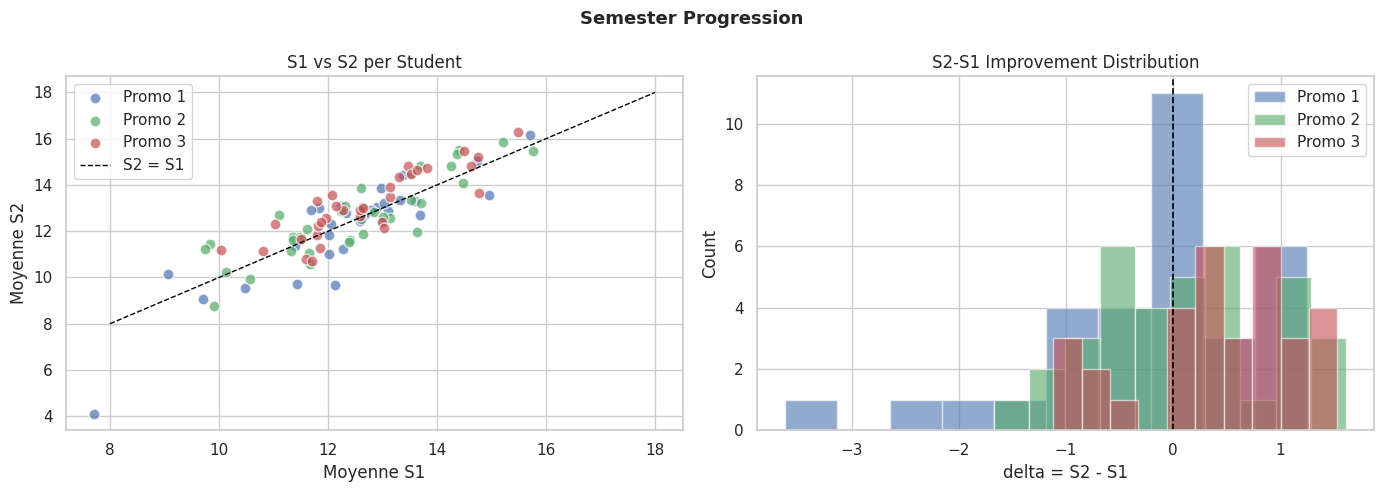


Mean S2-S1 delta by promo:
       mean  std
promo           
1     -0.21 1.06
2      0.13 0.83
3      0.42 0.73


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 6a. Scatter S1 vs S2, coloured by promo
ax = axes[0]
for promo in [1, 2, 3]:
    sub = panel[panel["promo"] == promo]
    ax.scatter(sub["moy_s1"], sub["moy_s2"], color=PROMO_COLORS[promo],
               alpha=0.7, label=f"Promo {promo}", edgecolors="white", s=60)
ax.plot([8, 18], [8, 18], "k--", lw=1, label="S2 = S1")
ax.set_xlabel("Moyenne S1")
ax.set_ylabel("Moyenne S2")
ax.set_title("S1 vs S2 per Student")
ax.legend()

# 6b. Delta S2-S1 by promo
ax = axes[1]
for promo in [1, 2, 3]:
    data = panel[panel["promo"] == promo]["delta_s2_s1"]
    ax.hist(data, bins=10, alpha=0.6, color=PROMO_COLORS[promo], label=f"Promo {promo}")
ax.axvline(0, color="black", lw=1.2, linestyle="--")
ax.set_xlabel("delta = S2 - S1")
ax.set_ylabel("Count")
ax.set_title("S2-S1 Improvement Distribution")
ax.legend()

fig.suptitle("Semester Progression", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "semester_progression.png", dpi=150)
plt.show()

delta_summary = panel.groupby("promo")["delta_s2_s1"].agg(["mean", "std"])
print("\nMean S2-S1 delta by promo:")
print(delta_summary.round(3))


## 7. Subject-Level Performance



In [ ]:
if grade_cols:
    subj_means = (notes
        .merge(matieres[["id_mat", "nom_mat", "nom_module", "semestre"]], on="id_mat", how="left")
        .merge(panel[["id", "promo"]], on="id", how="left")
    )

    # Mean grade per subject per promo
    subj_promo = (subj_means
        .groupby(["nom_mat", "promo"])["mg_mat"]
        .mean().unstack().round(2))
    print("Mean grade per subject per promo:")
    print(subj_promo)

    # Heatmap
    fig, ax = plt.subplots(figsize=(max(6, len(subj_promo.columns)*2.5),
                                    max(4, len(subj_promo)*0.6)))
    sns.heatmap(subj_promo, annot=True, fmt=".1f", cmap="RdYlGn",
                vmin=8, vmax=18, ax=ax, linewidths=0.5)
    ax.set_title("Mean Grade per Subject per Promotion")
    ax.set_xlabel("Promotion")
    ax.set_ylabel("Matière")
    plt.tight_layout()
    plt.savefig(FIG / "subject_heatmap.png", dpi=150)
    plt.show()


## 8. Top vs Bottom Students — Who Are They?



In [ ]:
top    = panel[panel["top_quartile"] == 1].sort_values("moy_ann", ascending=False)
bottom = panel[panel["bottom_quartile"] == 1].sort_values("moy_ann")

print(f"Top 25% (n={len(top)}) — mean annual avg: {top['moy_ann'].mean():.2f}")
print(top[["id", "promo", "moy_s1", "moy_s2", "moy_ann", "rang", "passage"]].head(10))

print(f"\nBottom 25% (n={len(bottom)}) — mean annual avg: {bottom['moy_ann'].mean():.2f}")
print(bottom[["id", "promo", "moy_s1", "moy_s2", "moy_ann", "rang", "passage"]].head(10))

# Promo breakdown of top/bottom
print("\nPromo share among top quartile:")
print(top["promo"].value_counts(normalize=True).round(2))
print("\nPromo share among bottom quartile:")
print(bottom["promo"].value_counts(normalize=True).round(2))


## 9. Demographic Breakdown (if profils joined)



In [ ]:
for demo in demo_cols:
    print(f"\n── {demo} ──")
    group_stats = (panel.groupby(demo)["moy_ann"]
                   .agg(["mean", "std", "count"]).round(2))
    print(group_stats)

    if panel[demo].nunique() <= 6:
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.boxplot(data=panel, x=demo, y="moy_ann", palette="Set2", ax=ax)
        ax.set_title(f"Annual Average by {demo}")
        ax.set_ylabel("Moyenne annuelle /20")
        plt.tight_layout()
        plt.savefig(FIG / f"demo_{demo}.png", dpi=150)
        plt.show()


## 10. Correlation Heatmap



In [ ]:
num_panel = panel[["moy_s1", "moy_s2", "moy_ann", "delta_s2_s1", "rang",
                   "passage_bin"] + grade_cols + mod_cols].dropna(axis=1, how="all")
corr = num_panel.corr()

fig, ax = plt.subplots(figsize=(max(8, len(corr)*0.7), max(6, len(corr)*0.7)))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.3)
ax.set_title("Correlation Matrix — All Numeric Variables")
plt.tight_layout()
plt.savefig(FIG / "correlation_matrix.png", dpi=150)
plt.show()


## 11. Rank vs Grade Consistency



In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for promo in [1, 2, 3]:
    sub = panel[panel["promo"] == promo]
    ax.scatter(sub["rang"], sub["moy_ann"], color=PROMO_COLORS[promo],
               alpha=0.7, label=f"Promo {promo}", s=50, edgecolors="white")
ax.set_xlabel("Rang (1 = best in promo)")
ax.set_ylabel("Moyenne annuelle /20")
ax.set_title("Rank vs Annual Average (by Promo)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "rank_vs_avg.png", dpi=150)
plt.show()
